<!-- STATUS_BLOCK_v1 -->
# flower_visit_pipeline.ipynb — STATUS

**Pipeline position:** Pipeline [1] of [4]

**Purpose.**  Detect bumblebee flower visits from PATS-C tracks (within-track stationary + cross-track endpoint pairs with a deceleration gate), then aggregate per (date, system).

**Inputs:**  `data/flight_data/<date>_system_<sys>/{detections.csv, flight_tracks.csv}`
**Outputs:** `data/multi_day/flower_visits.csv`, `flower_visits_rejected.csv`, `flower_visit_summary.csv`

### WORKS
- **Wall-clock linker** — every track is anchored to its wall-clock start (`detections.datetime`); cross-track links compare wall-clock, not raw `elapsed`. This fixes the chunk-reset bug where `elapsed` restarts every ~50-min recording and paired tracks from different chunks.
- Within-track stationary-segment detection (1-second displacement < 5 cm)
- Cross-track endpoint linking with deceleration gate (end speed < 0.5 m/s)
- Spatial filters: **hive square box**, **full-height 15×15 cm post**, **y-ceiling**, FOV-edge buffer (0.15 m)
- Per-system FOV bounds estimated empirically from valid frames
- Greedy single-link clustering of visits into individual flowers
- `flower_visits.csv` carries wall-clock columns `t_start_dt` / `t_end_dt`
- Section 5b prints per-visit uids + wall-clock times and plots their raw trajectories for video download

### PENDING
- Confirm the hive-box half-extents (`HIVE_HALF_X/Y/Z`) against the real hive dimensions — defaults are a 30 cm cube, a superset of the old 0.15 m sphere
- Tune `MIN_VISIT_S` if the per-visit duration distribution is too noisy

## Pipeline flow (canonical)

```
data/flight_data/<date>_system_<sys>/                  ← raw PATS-C output
       │
       ▼
[1] flower_visit_pipeline.ipynb                        slow; run when raw data changes
       └── data/multi_day/flower_visit_summary.csv

[2] multi_day_pipeline.ipynb                           always run after raw data updates
       ├── data/multi_day/daily_summary.csv
       ├── data/multi_day/per_track_indicators.csv
       └── data/multi_day/indicators_daily.csv         ← the file the model consumes

       (uses outputs of [1] + dBm + data transfer)
       │
       ▼
[3] validation.ipynb / indicator_validation.ipynb      QC
       │
       ▼
[4] exposure_analysis.ipynb / 5g_foraging_effect_model.ipynb
       │
       ▼
[5] statistical_methods.ipynb                          reading guide
```

---


# Flower-visit aggregation pipeline (wall-clock, box-hive, full post, ceiling)

Sweeps every `<date>_system_<sys>` folder in `data/flight_data/`, runs the
within-track + cross-track flower-visit detector on a **wall-clock timeline**,
then applies quality filters and emits aggregated indicators.

### The wall-clock fix (why this version exists)

`flight_tracks.csv` has an `elapsed` column that **restarts at ~0 every recording
chunk** (~50 min). The old cross-track linker compared two tracks' raw `elapsed`
values, so a track at the end of one chunk could be "linked" to a track at the
start of the next — a spurious visit. We now anchor every track to its wall-clock
start time from `detections.csv` (`datetime`, e.g. `20260413_133131`) and link on
wall-clock. (`elapsed` is still used to order frames *within* a single track,
which never spans a chunk boundary, so that is safe.)

### The two flower-visit scenarios

1. **within-track** — a single track contains a contiguous stretch `≥ MIN_VISIT_S`
   where the bee's 3D displacement over a 1-second window is `< DISP_THR_M`
   (default 5 cm). The bee is parked on a flower.
2. **cross-track** — track A's last (x,y,z) is within `LINK_DIST_M` of track B's
   first (x,y,z), and B starts between `MIN_VISIT_S` and `LINK_DT_MAX_S` after A
   ends **in wall-clock time**. We require track A to be **decelerating to
   `< DECEL_END_THR_MS` m/s** in its last `VEL_WINDOW` frames.

### Filters applied after detection

| filter | rule | rationale |
|---|---|---|
| `hive` | inside the hive **box**: `|x−hₓ|<HIVE_HALF_X` & `|y−h_y|<HIVE_HALF_Y` & `|z−h_z|<HIVE_HALF_Z` | the hive is a square box; a bee landing on its face/corner is not on a flower |
| `post` | `|x−hₓ| < POST_HALF_WIDTH_M` & `|z−h_z| < POST_HALF_WIDTH_M`, **full y height** | bee behind the 15×15 cm mounting post, which spans the whole frame top-to-bottom |
| `above_ceiling` | `y > hive_y + Y_CEILING_BUFFER_M` (per system) | almost no flowers above the hive entrance; a 10 cm buffer absorbs stereo/calibration error (900→−0.565, 939→−0.728) |
| `fov_edge` | within `EDGE_BUFFER_M` of any axis's 1st/99th-percentile boundary | bee entering/leaving the camera FOV, not a landing |
| `end_velocity` | (cross-track only) track A not decelerating, or end-mean speed ≥ `DECEL_END_THR_MS` | A was still cruising → the cross-track pair is a tracking dropout |

Rejected visits are kept in `flower_visits_rejected.csv` for audit.

### Outputs

- `data/multi_day/flower_visits.csv` — accepted visits, one row each, **with wall-clock `t_start_dt`/`t_end_dt`**
- `data/multi_day/flower_visits_rejected.csv` — rejected visits + `filter_reason`
- `data/multi_day/flower_visit_summary.csv` — per (date, system_id) indicators


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import re

import numpy as np
import pandas as pd

# ── detector knobs ──
DISP_WINDOW_S    = 1.0
DISP_THR_M       = 0.05
MIN_VISIT_S      = 1.0
LINK_DIST_M      = 0.10
LINK_DT_MAX_S    = 30.0
CLUSTER_RADIUS_M = 0.15

# ── HIVE geometry — HIVE_XYZ marks the ENTRANCE (top-front edge of the cube) ──
# HIVE_XYZ is the bee-facing point of the hive (entrance), NOT the geometric
# centre.  The cube extends from the entrance:
#   x:  ± HIVE_HALF_X       (entrance is centred horizontally)
#   y:  DOWN by HIVE_DOWN_Y (entrance is at the TOP edge of the front face)
#   z:  BACK by HIVE_BACK_Z (entrance is at the FRONT face — closest to camera)
# All in metres.  Result: a 30 cm cube whose front-top edge sits at HIVE_XYZ.
HIVE_HALF_X = 0.15    # ±15 cm in x around the entrance
HIVE_DOWN_Y = 0.30    # 30 cm DOWN from the entrance in y
HIVE_BACK_Z = 0.30    # 30 cm BACK from the entrance in z (away from camera)

# ── POST = 15×15 cm column BEHIND the hive's back face ──
# The hive is bolted to the FRONT face of the post.  Post xz cross-section is
# 2*POST_HALF_WIDTH_M wide; post spans the full y height of the frame.
POST_HALF_WIDTH_M = 0.075   # 15 × 15 cm cross-section

# ── CEILING (per-system) ──
# Almost no flowers above the hive entrance. Reject visits whose y is above the
# hive's own entrance height plus a small buffer for stereo/calibration error.
#   ceiling_y(sys) = hive_y(sys) + Y_CEILING_BUFFER_M
#   900: -0.665 + 0.10 = -0.565      939: -0.828 + 0.10 = -0.728
Y_CEILING_BUFFER_M = 0.10

# ── FOV-edge buffer ──
EDGE_BUFFER_M = 0.10        # buffer from per-axis 1st/99th percentile

# ── deceleration check (cross-track only) ──
VEL_WINDOW          = 10    # trailing frames considered for track A
DECEL_END_THR_MS    = 0.5   # mean speed over last half of window must be below this
DECEL_SLOPE_THR_MS  = 0.0   # slope of speed vs time (m/s²) must be <= this
DECEL_DROP_RATIO    = 0.7   # second-half mean ≤ this × first-half mean (≥30% drop)

# ── hive positions (x, y, z) ──
HIVE_XYZ = {900: (-0.040, -0.665, -1.195),
            939: (-0.086, -0.828, -1.045)}

# ── post positions (x, z) — auto-computed from hive entrance + geometry ──
# Post centre x  = hive entrance x  (hive mounted on the post's front face)
# Post centre z  = hive_z - HIVE_BACK_Z - POST_HALF_WIDTH_M
#                  (post's front face touches the hive's back face)
POST_XZ = {sid: (hxyz[0], hxyz[2] - HIVE_BACK_Z - POST_HALF_WIDTH_M)
           for sid, hxyz in HIVE_XYZ.items()}

DATA_BASE = Path("../../data/flight_data")
OUT_DIR   = Path("data/multi_day")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FOLDER_RE = re.compile(r"^(\d{4}-\d{2}-\d{2})_system_(\d+)$")

print(f"Source: {DATA_BASE.resolve()}")
print(f"Output: {OUT_DIR.resolve()}")
print(f"Hive box: {2*HIVE_HALF_X*100:.0f} × {HIVE_DOWN_Y*100:.0f} × {HIVE_BACK_Z*100:.0f} cm "
      f"(entrance at HIVE_XYZ; extends down in y, back in z)")
print(f"Post:     {2*POST_HALF_WIDTH_M*100:.0f} × {2*POST_HALF_WIDTH_M*100:.0f} cm xz column, full height, behind hive")
print(f"Per-system POST_XZ (auto): {POST_XZ}")
print(f"Ceiling:  reject visits with y > hive_y + {Y_CEILING_BUFFER_M} m (per system)")
print(f"FOV edge buffer: {EDGE_BUFFER_M*100:.0f} cm")
print(f"Cross-track deceleration: end-mean ≤ {DECEL_END_THR_MS} m/s, "
      f"slope ≤ {DECEL_SLOPE_THR_MS} m/s², drop-ratio ≤ {DECEL_DROP_RATIO}")


Source: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/data/flight_data
Output: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/pats/data/multi_day
Hive box: 30 × 30 × 30 cm (entrance at HIVE_XYZ; extends down in y, back in z)
Post:     15 × 15 cm xz column, full height, behind hive
Per-system POST_XZ (auto): {900: (-0.04, -1.57), 939: (-0.086, -1.42)}
Ceiling:  reject visits with y > hive_y + 0.1 m (per system)
FOV edge buffer: 10 cm
Cross-track deceleration: end-mean ≤ 0.5 m/s, slope ≤ 0.0 m/s², drop-ratio ≤ 0.7


## 1. Detector + wall-clock + deceleration functions

`build_track_anchors` maps each `detection_uid` to `(wall_start, first_elapsed)`,
where `wall_start` is the track's wall-clock start from `detections.csv`. Any
frame's wall-clock time is `wall_start + (elapsed − first_elapsed)`. Because a
single track never spans a recording-chunk boundary, this is exact within a track
and **comparable across tracks** — which is what the cross-track linker needs.

`track_endpoint_kinematics` returns terminal-speed descriptors per track, and
`is_decelerating` encodes the cross-track landing gate (terminal speed below
`DECEL_END_THR_MS`, and either a negative slope or a ≥30% drop).


In [2]:
def per_track_stationary_segments(ft_sub, disp_window_s, disp_thr, min_visit_s):
    """Scenario 1: within-track stationary segments (bee parked on a flower).
    Returns list of (t0_elapsed, t1_elapsed, x, y, z)."""
    if len(ft_sub) < 30: return []
    times = ft_sub["elapsed"].values
    xs = ft_sub["sposX_insect"].values
    ys = ft_sub["sposY_insect"].values
    zs = ft_sub["sposZ_insect"].values
    disp = np.full(len(ft_sub), np.nan)
    j = 0
    for i in range(len(ft_sub)):
        while j < i and times[i] - times[j] >= disp_window_s:
            j += 1
        ref = max(0, j - 1)
        if i - ref >= 5:
            disp[i] = np.sqrt((xs[i]-xs[ref])**2 + (ys[i]-ys[ref])**2 + (zs[i]-zs[ref])**2)
    stat = (disp < disp_thr) & ~np.isnan(disp)

    out, in_run, rs = [], False, 0
    for i, s in enumerate(stat):
        if s and not in_run: rs = i; in_run = True
        elif not s and in_run:
            t0, t1 = times[rs], times[i-1]
            if t1 - t0 >= min_visit_s:
                out.append((t0, t1, xs[rs:i].mean(), ys[rs:i].mean(), zs[rs:i].mean()))
            in_run = False
    if in_run:
        t0, t1 = times[rs], times[-1]
        if t1 - t0 >= min_visit_s:
            out.append((t0, t1, xs[rs:].mean(), ys[rs:].mean(), zs[rs:].mean()))
    return out


def track_endpoint_kinematics(ft, n_window):
    """Per-uid terminal/leading speed descriptors (for the deceleration gate)."""
    out = {}
    for uid, sub in ft.groupby("detection_uid"):
        sub = sub.sort_values("elapsed")
        valid = sub[sub["vel_valid_insect"] == 1] if "vel_valid_insect" in sub.columns else sub
        rec = {"end_mean_v": np.nan, "end_full_mean_v": np.nan,
               "end_slope_v": np.nan, "end_first_half_v": np.nan,
               "end_second_half_v": np.nan, "start_mean_v": np.nan}
        if len(valid) >= 4:
            tail = valid.tail(n_window)
            t = tail["elapsed"].values.astype(float)
            sp = np.sqrt(tail["svelX_insect"]**2 + tail["svelY_insect"]**2 + tail["svelZ_insect"]**2).values
            rec["end_full_mean_v"] = float(np.mean(sp))
            half = max(2, len(sp) // 2)
            rec["end_first_half_v"]  = float(np.mean(sp[:half]))
            rec["end_second_half_v"] = float(np.mean(sp[-half:]))
            rec["end_mean_v"]        = rec["end_second_half_v"]
            if len(t) >= 3 and (t[-1] - t[0]) > 1e-6:
                rec["end_slope_v"] = float(np.polyfit(t - t[0], sp, 1)[0])
            head = valid.head(n_window)
            sp0 = np.sqrt(head["svelX_insect"]**2 + head["svelY_insect"]**2 + head["svelZ_insect"]**2).values
            rec["start_mean_v"] = float(np.mean(sp0))
        out[uid] = rec
    return out


def is_decelerating(kin, end_thr, slope_thr, drop_ratio):
    """True if the bee was decelerating to land at the end of track A."""
    if not np.isfinite(kin["end_mean_v"]):
        return False, "no_kinematics"
    if kin["end_mean_v"] >= end_thr:
        return False, "end_v_too_high"
    decel_slope = np.isfinite(kin["end_slope_v"]) and (kin["end_slope_v"] < slope_thr)
    decel_drop  = (np.isfinite(kin["end_first_half_v"]) and kin["end_first_half_v"] > 1e-3
                   and (kin["end_second_half_v"] <= drop_ratio * kin["end_first_half_v"]))
    if not (decel_slope or decel_drop):
        return False, "no_deceleration"
    return True, "ok"


# ───────────────────────── WALL-CLOCK ─────────────────────────
def load_detection_walls(folder):
    """uid -> wall-clock track-start Timestamp, parsed from detections.csv `datetime`."""
    det_csv = folder / "detections.csv"
    if not det_csv.exists():
        return {}
    det = pd.read_csv(det_csv, usecols=["uid", "datetime"])
    det["wall"] = pd.to_datetime(det["datetime"], format="%Y%m%d_%H%M%S", errors="coerce")
    return {int(u): w for u, w in zip(det["uid"], det["wall"]) if pd.notna(w)}


def build_track_anchors(ft, det_wall):
    """uid -> (wall_start Timestamp|NaT, first_elapsed float)."""
    fe = ft.groupby("detection_uid")["elapsed"].min()
    return {int(uid): (det_wall.get(int(uid), pd.NaT), float(f)) for uid, f in fe.items()}


def elapsed_to_wall(uid, elapsed, anchors):
    ws, fe = anchors.get(int(uid), (pd.NaT, np.nan))
    if pd.isna(ws):
        return pd.NaT
    return ws + pd.to_timedelta(float(elapsed) - fe, unit="s")


def track_endpoints(ft, anchors):
    g = ft.sort_values("elapsed").groupby("detection_uid")
    first = g.first(); last = g.last()
    uids = first.index.to_numpy()
    le = g["elapsed"].max()
    wall0, wall1 = [], []
    for uid in uids:
        ws, fe = anchors.get(int(uid), (pd.NaT, np.nan))
        if pd.isna(ws):
            wall0.append(pd.NaT); wall1.append(pd.NaT)
        else:
            wall0.append(ws)                                            # first frame == track start
            wall1.append(ws + pd.to_timedelta(float(le[uid]) - fe, unit="s"))
    return pd.DataFrame({
        "uid": uids,
        "t0": first["elapsed"].values, "t1": last["elapsed"].values,
        "wall0": pd.to_datetime(pd.Series(wall0)), "wall1": pd.to_datetime(pd.Series(wall1)),
        "x0": first["sposX_insect"].values, "y0": first["sposY_insect"].values, "z0": first["sposZ_insect"].values,
        "x1": last["sposX_insect"].values,  "y1": last["sposY_insect"].values,  "z1": last["sposZ_insect"].values,
        "n_frames": g.size().values,
    }).reset_index(drop=True)


def detect_visits_one_day(ft, hive_xyz, anchors):
    """Scenario-1 (within-track) + scenario-2 (cross-track, wall-clock linked)."""
    kin_by_uid = track_endpoint_kinematics(ft, VEL_WINDOW)

    # — Scenario 1: within-track stationary segments —
    within = []
    for uid, sub in ft.sort_values("elapsed").groupby("detection_uid"):
        for t0, t1, x, y, z in per_track_stationary_segments(
                sub, DISP_WINDOW_S, DISP_THR_M, MIN_VISIT_S):
            within.append({
                "source": "within",
                "wall_start": elapsed_to_wall(uid, t0, anchors),
                "wall_end":   elapsed_to_wall(uid, t1, anchors),
                "x": x, "y": y, "z": z, "duration_s": t1 - t0,
                "uids": [int(uid)],
                "end_v_a": np.nan, "end_slope_a": np.nan,
                "end_first_half_v_a": np.nan, "end_second_half_v_a": np.nan,
                "start_v_b": np.nan,
            })

    # — Scenario 2: cross-track pair, WALL-CLOCK linked, with deceleration gate —
    endpoints = track_endpoints(ft, anchors).sort_values("wall1").reset_index(drop=True)
    min_gap = pd.Timedelta(seconds=MIN_VISIT_S)
    max_gap = pd.Timedelta(seconds=LINK_DT_MAX_S)
    cross, rejected_decel = [], []
    for _, a in endpoints.iterrows():
        if pd.isna(a["wall1"]):
            continue
        kin_a = kin_by_uid.get(a["uid"], None)
        if kin_a is None:
            continue
        cand = endpoints[(endpoints["wall0"] > a["wall1"] + min_gap) &
                         (endpoints["wall0"] < a["wall1"] + max_gap) &
                         (endpoints["uid"] != a["uid"])]
        if cand.empty:
            continue
        d = np.sqrt((cand["x0"]-a["x1"])**2 + (cand["y0"]-a["y1"])**2 + (cand["z0"]-a["z1"])**2)
        cand = cand.assign(d=d.values)
        cand = cand[cand["d"] < LINK_DIST_M]
        if cand.empty:
            continue
        b = cand.sort_values("wall0").iloc[0]
        kin_b = kin_by_uid.get(int(b["uid"]), None)
        start_v_b = kin_b["start_mean_v"] if kin_b is not None else np.nan

        rec = {"source": "cross",
               "wall_start": a["wall1"], "wall_end": b["wall0"],
               "x": 0.5*(a["x1"]+b["x0"]), "y": 0.5*(a["y1"]+b["y0"]), "z": 0.5*(a["z1"]+b["z0"]),
               "duration_s": (b["wall0"] - a["wall1"]).total_seconds(),
               "uids": [int(a["uid"]), int(b["uid"])],
               "end_v_a":            kin_a["end_mean_v"],
               "end_slope_a":        kin_a["end_slope_v"],
               "end_first_half_v_a":  kin_a["end_first_half_v"],
               "end_second_half_v_a": kin_a["end_second_half_v"],
               "start_v_b":          start_v_b}

        ok, why = is_decelerating(kin_a, DECEL_END_THR_MS, DECEL_SLOPE_THR_MS, DECEL_DROP_RATIO)
        if not ok:
            rec["filter_reason"] = "end_velocity"
            rec["decel_fail_reason"] = why
            rejected_decel.append(rec)
        else:
            cross.append(rec)

    visits = within + cross
    cols = ["source","wall_start","wall_end","x","y","z","duration_s","uids",
            "end_v_a","end_slope_a","end_first_half_v_a","end_second_half_v_a",
            "start_v_b","dist_hive_m","filter_reason"]
    df     = pd.DataFrame(visits) if visits else pd.DataFrame(columns=cols)
    rej_df = pd.DataFrame(rejected_decel)

    hx, hy, hz = hive_xyz
    if not df.empty:
        df["dist_hive_m"] = np.sqrt((df["x"]-hx)**2 + (df["y"]-hy)**2 + (df["z"]-hz)**2)
    if not rej_df.empty:
        rej_df["dist_hive_m"] = np.sqrt((rej_df["x"]-hx)**2 + (rej_df["y"]-hy)**2 + (rej_df["z"]-hz)**2)
    return df, rej_df


def apply_spatial_filters(df, hive_xyz, fov_bounds, post_xz):
    """Mark visits with filter_reason: hive (box) / post (full-height) / above_ceiling / fov_edge.

    `post_xz` is the (x, z) centre of the mounting pole (BEHIND the hive),
    not the hive centre.  The post is a 15×15 cm xz column spanning the
    full y range of the frame.
    """
    if df.empty:
        df["filter_reason"] = None
        return df
    hx, hy, hz = hive_xyz
    px, pz     = post_xz
    x_lo, x_hi = fov_bounds["x"]; y_lo, y_hi = fov_bounds["y"]; z_lo, z_hi = fov_bounds["z"]
    reason = pd.Series([None]*len(df), index=df.index, dtype=object)

    # 1. hive cube — HIVE_XYZ is the ENTRANCE (top-front edge of the cube):
    #    cube extends ±HIVE_HALF_X in x, hy-HIVE_DOWN_Y..hy in y,
    #    hz-HIVE_BACK_Z..hz in z (back of cube is more negative z)
    in_hive = ((np.abs(df["x"] - hx) < HIVE_HALF_X) &
               (df["y"] >= hy - HIVE_DOWN_Y) & (df["y"] <= hy) &
               (df["z"] >= hz - HIVE_BACK_Z) & (df["z"] <= hz))
    reason.loc[(reason.isna()) & in_hive] = "hive"

    # 2. 15×15 cm post BEHIND the hive: xz cross-section centred on (px, pz),
    #    full y height
    in_post = ((np.abs(df["x"] - px) < POST_HALF_WIDTH_M) &
               (np.abs(df["z"] - pz) < POST_HALF_WIDTH_M))
    reason.loc[(reason.isna()) & in_post] = "post"

    # 3. ceiling: almost no flowers above the hive entrance (per-system: hive_y + buffer)
    y_ceiling = hy + Y_CEILING_BUFFER_M
    reason.loc[(reason.isna()) & (df["y"] > y_ceiling)] = "above_ceiling"

    # 4. FOV edges (any of 6 axis-aligned planes)
    near = ((df["x"] < x_lo + EDGE_BUFFER_M) | (df["x"] > x_hi - EDGE_BUFFER_M) |
            (df["y"] < y_lo + EDGE_BUFFER_M) | (df["y"] > y_hi - EDGE_BUFFER_M) |
            (df["z"] < z_lo + EDGE_BUFFER_M) | (df["z"] > z_hi - EDGE_BUFFER_M))
    reason.loc[(reason.isna()) & near] = "fov_edge"

    df["filter_reason"] = reason
    return df


def cluster_into_flowers(visits, radius=CLUSTER_RADIUS_M):
    flower_id = np.full(len(visits), -1, dtype=int)
    next_id = 0
    for i in range(len(visits)):
        if flower_id[i] != -1: continue
        flower_id[i] = next_id
        queue = [i]
        while queue:
            k = queue.pop()
            for j in range(len(visits)):
                if flower_id[j] != -1: continue
                d = np.sqrt((visits.iloc[k]["x"]-visits.iloc[j]["x"])**2 +
                            (visits.iloc[k]["y"]-visits.iloc[j]["y"])**2 +
                            (visits.iloc[k]["z"]-visits.iloc[j]["z"])**2)
                if d < radius:
                    flower_id[j] = next_id; queue.append(j)
        next_id += 1
    return flower_id


## 2. Compute FOV bounds per system from valid frames

The 1st and 99th percentile of all valid bee positions across the
experimental window give an empirical tracking-volume boundary per
system.  Visits within `EDGE_BUFFER_M` (= 15 cm) of any of those bounds
get the `fov_edge` filter reason.


In [3]:
SAMPLE_DAYS_PER_SYS = {900: ["2026-04-18", "2026-04-27", "2026-05-02"],
                       939: ["2026-04-23", "2026-05-02", "2026-05-08"]}

fov_bounds = {}
for sid, days in SAMPLE_DAYS_PER_SYS.items():
    xs, ys, zs = [], [], []
    for d in days:
        folder = DATA_BASE / f"{d}_system_{sid}"
        ft_csv = folder / "flight_tracks.csv"
        if not ft_csv.exists(): continue
        ft = pd.read_csv(ft_csv, usecols=["pos_valid_insect",
                                           "sposX_insect", "sposY_insect", "sposZ_insect"])
        ft = ft[ft["pos_valid_insect"] == 1]
        xs.append(ft["sposX_insect"]); ys.append(ft["sposY_insect"]); zs.append(ft["sposZ_insect"])
    x = pd.concat(xs); y = pd.concat(ys); z = pd.concat(zs)
    fov_bounds[sid] = {
        "x": (float(np.percentile(x, 1)), float(np.percentile(x, 99))),
        "y": (float(np.percentile(y, 1)), float(np.percentile(y, 99))),
        "z": (float(np.percentile(z, 1)), float(np.percentile(z, 99))),
    }
    print(f"sys {sid} FOV bounds (1-99 pct from {len(x):,} valid frames):")
    print(f"  x: {fov_bounds[sid]['x'][0]:+.3f} -> {fov_bounds[sid]['x'][1]:+.3f}")
    print(f"  y: {fov_bounds[sid]['y'][0]:+.3f} -> {fov_bounds[sid]['y'][1]:+.3f}")
    print(f"  z: {fov_bounds[sid]['z'][0]:+.3f} -> {fov_bounds[sid]['z'][1]:+.3f}")


sys 900 FOV bounds (1-99 pct from 1,084,985 valid frames):
  x: -1.715 -> +1.826
  y: -1.297 -> -0.133
  z: -3.539 -> -0.432
sys 939 FOV bounds (1-99 pct from 490,043 valid frames):
  x: -1.874 -> +1.350
  y: -1.543 -> -0.179
  z: -3.282 -> -0.356


## 3. Sweep all day-system folders

In [4]:
all_kept_rows = []
all_rejected_rows = []
summary_rows = []

def _secs_of_day(ts):
    if pd.isna(ts): return np.nan
    return ts.hour*3600 + ts.minute*60 + ts.second + ts.microsecond/1e6

def _iso(ts):
    return ts.isoformat() if pd.notna(ts) else ""

folders = sorted(DATA_BASE.glob("*_system_*"))
print(f"Sweeping {len(folders)} folders ...")
for folder in folders:
    m = FOLDER_RE.match(folder.name)
    if not m: continue
    date_str, sys_str = m.groups()
    sid = int(sys_str)
    if sid not in HIVE_XYZ:
        print(f"  skip {folder.name}: unknown system"); continue
    ft_csv = folder / "flight_tracks.csv"
    if not ft_csv.exists():
        print(f"  skip {folder.name}: no flight_tracks.csv"); continue

    ft = pd.read_csv(ft_csv, usecols=["detection_uid", "elapsed",
                                       "sposX_insect", "sposY_insect", "sposZ_insect",
                                       "svelX_insect", "svelY_insect", "svelZ_insect",
                                       "vel_valid_insect"])
    det_wall = load_detection_walls(folder)          # uid -> wall-clock start
    anchors  = build_track_anchors(ft, det_wall)     # uid -> (wall_start, first_elapsed)

    cand_df, rej_endv_df = detect_visits_one_day(ft, HIVE_XYZ[sid], anchors)
    cand_df = apply_spatial_filters(cand_df, HIVE_XYZ[sid], fov_bounds[sid], POST_XZ[sid])

    kept = cand_df[cand_df["filter_reason"].isna()].copy()
    rejected = pd.concat([cand_df[cand_df["filter_reason"].notna()], rej_endv_df], ignore_index=True)

    n_within_kept = (kept["source"] == "within").sum() if not kept.empty else 0
    n_cross_kept  = (kept["source"] == "cross").sum() if not kept.empty else 0
    rej_summary = ', '.join(f'{r}={n}' for r, n in rejected["filter_reason"].value_counts().items()) if len(rejected) else ""
    print(f"  {date_str}  sys {sid}:  "
          f"kept={len(kept):3d} (within={n_within_kept}, cross={n_cross_kept})  "
          f"rejected={len(rejected):3d}  ({rej_summary})")

    if not kept.empty:
        kept = kept.assign(flower_id=cluster_into_flowers(kept))
        for _, v in kept.iterrows():
            all_kept_rows.append({
                "date": date_str, "system_id": sid,
                "t_start_dt": _iso(v["wall_start"]), "t_end_dt": _iso(v["wall_end"]),
                "t_start_s": _secs_of_day(v["wall_start"]), "t_end_s": _secs_of_day(v["wall_end"]),
                "duration_s": float(v["duration_s"]),
                "x": float(v["x"]), "y": float(v["y"]), "z": float(v["z"]),
                "dist_hive_m": float(v["dist_hive_m"]),
                "end_v_a":          float(v["end_v_a"])          if pd.notna(v["end_v_a"])          else np.nan,
                "end_slope_a":      float(v["end_slope_a"])      if pd.notna(v["end_slope_a"])      else np.nan,
                "end_first_half_v_a":  float(v["end_first_half_v_a"])  if pd.notna(v["end_first_half_v_a"])  else np.nan,
                "end_second_half_v_a": float(v["end_second_half_v_a"]) if pd.notna(v["end_second_half_v_a"]) else np.nan,
                "start_v_b":        float(v["start_v_b"])        if pd.notna(v["start_v_b"])        else np.nan,
                "source": v["source"],
                "uids": ";".join(str(u) for u in v["uids"]),
                "flower_id": int(v["flower_id"]),
            })

        n_visits  = len(kept)
        n_flowers = kept["flower_id"].nunique()
        summary_rows.append({
            "date": date_str, "system_id": sid,
            "n_visits": n_visits,
            "mean_handling_time_s":   float(kept["duration_s"].mean()),
            "median_handling_time_s": float(kept["duration_s"].median()),
            "total_visit_time_s":     float(kept["duration_s"].sum()),
            "n_distinct_flowers":     int(n_flowers),
            "revisit_rate":           n_visits / n_flowers if n_flowers else np.nan,
        })
    else:
        summary_rows.append({
            "date": date_str, "system_id": sid,
            "n_visits": 0, "mean_handling_time_s": np.nan,
            "median_handling_time_s": np.nan, "total_visit_time_s": 0.0,
            "n_distinct_flowers": 0, "revisit_rate": np.nan,
        })

    for _, v in rejected.iterrows():
        all_rejected_rows.append({
            "date": date_str, "system_id": sid,
            "t_start_dt": _iso(v["wall_start"]) if pd.notna(v.get("wall_start")) else "",
            "t_end_dt":   _iso(v["wall_end"])   if pd.notna(v.get("wall_end"))   else "",
            "duration_s": float(v["duration_s"]),
            "x": float(v["x"]), "y": float(v["y"]), "z": float(v["z"]),
            "end_v_a":          float(v["end_v_a"])          if pd.notna(v.get("end_v_a"))          else np.nan,
            "end_slope_a":      float(v["end_slope_a"])      if pd.notna(v.get("end_slope_a"))      else np.nan,
            "end_first_half_v_a":  float(v["end_first_half_v_a"])  if pd.notna(v.get("end_first_half_v_a"))  else np.nan,
            "end_second_half_v_a": float(v["end_second_half_v_a"]) if pd.notna(v.get("end_second_half_v_a")) else np.nan,
            "source": v["source"],
            "uids": ";".join(str(u) for u in v["uids"]),
            "filter_reason":    v["filter_reason"],
            "decel_fail_reason": v.get("decel_fail_reason", None),
        })

print(f"\nDone.  Total kept: {len(all_kept_rows):,}  Total rejected: {len(all_rejected_rows):,}")


Sweeping 82 folders ...
  2026-04-13  sys 900:  kept= 30 (within=21, cross=9)  rejected=  5  (end_velocity=3, fov_edge=2)
  2026-04-14  sys 900:  kept= 56 (within=28, cross=28)  rejected= 24  (end_velocity=11, above_ceiling=9, fov_edge=4)
  2026-04-15  sys 900:  kept= 87 (within=40, cross=47)  rejected= 18  (end_velocity=15, above_ceiling=3)
  2026-04-16  sys 900:  kept= 46 (within=24, cross=22)  rejected= 17  (end_velocity=9, above_ceiling=8)
  2026-04-17  sys 900:  kept= 85 (within=26, cross=59)  rejected= 15  (end_velocity=8, above_ceiling=7)
  2026-04-18  sys 900:  kept=328 (within=60, cross=268)  rejected= 42  (end_velocity=29, above_ceiling=12, hive=1)
  2026-04-19  sys 900:  kept= 68 (within=27, cross=41)  rejected= 26  (above_ceiling=14, end_velocity=11, hive=1)
  2026-04-20  sys 900:  kept=104 (within=39, cross=65)  rejected= 33  (above_ceiling=13, fov_edge=8, end_velocity=7, hive=5)
  2026-04-21  sys 900:  kept= 60 (within=29, cross=31)  rejected= 19  (end_velocity=10, above_

## 4. Write outputs

In [5]:
kept_df     = pd.DataFrame(all_kept_rows)
rejected_df = pd.DataFrame(all_rejected_rows)
summary_df  = (pd.DataFrame(summary_rows)
                 .sort_values(["system_id", "date"])
                 .reset_index(drop=True))

kept_df.to_csv(OUT_DIR / "flower_visits.csv", index=False)
rejected_df.to_csv(OUT_DIR / "flower_visits_rejected.csv", index=False)
summary_df.to_csv(OUT_DIR / "flower_visit_summary.csv", index=False)

print(f"Wrote:")
print(f"  {OUT_DIR/'flower_visits.csv'}            ({len(kept_df):,} kept visits)")
print(f"  {OUT_DIR/'flower_visits_rejected.csv'}   ({len(rejected_df):,} rejected, with filter_reason)")
print(f"  {OUT_DIR/'flower_visit_summary.csv'}     ({len(summary_df):,} day-system rows)")

print()
print("Rejection breakdown:")
if len(rejected_df):
    print(rejected_df["filter_reason"].value_counts().to_string())
    end_velocity_rej = rejected_df[rejected_df["filter_reason"] == "end_velocity"]
    if "decel_fail_reason" in end_velocity_rej.columns and end_velocity_rej["decel_fail_reason"].notna().any():
        print("\nWhich deceleration sub-check fired (end_velocity rows only):")
        print(end_velocity_rej["decel_fail_reason"].value_counts().to_string())
else:
    print("  (no rejections)")
print()
print("Summary preview:")
print(summary_df.to_string(index=False))


Wrote:
  data/multi_day/flower_visits.csv            (3,193 kept visits)
  data/multi_day/flower_visits_rejected.csv   (1,135 rejected, with filter_reason)
  data/multi_day/flower_visit_summary.csv     (82 day-system rows)

Rejection breakdown:
filter_reason
end_velocity     498
above_ceiling    291
hive             234
fov_edge         112

Which deceleration sub-check fired (end_velocity rows only):
decel_fail_reason
end_v_too_high     255
no_deceleration    243

Summary preview:
      date  system_id  n_visits  mean_handling_time_s  median_handling_time_s  total_visit_time_s  n_distinct_flowers  revisit_rate
2026-04-13        900        30              3.532315                1.530035          105.969443                   6      5.000000
2026-04-14        900        56              6.551293                3.177031          366.872396                   7      8.000000
2026-04-15        900        87              6.396789                2.642387          556.520625                  10

## 5. Sanity plot: top + front view per system

For each PATS camera we draw two projections of the kept and rejected visits:
- **Top view (`xz`)** — looking down on the greenhouse. The PATS camera sits at the
  origin `(x, z) = (0, 0)`; the dotted blue lines show the FOV cone in `x` at the
  far `z` boundary. Hive box and post cross-section are overlaid.
- **Front view (`xy`)** — looking at the camera face. Hive box, full-height post,
  the `y = -0.5` flower-ceiling, and the FOV-edge buffer (orange dotted lines) are
  overlaid.

Green = kept visits; coloured = rejected by `filter_reason`.


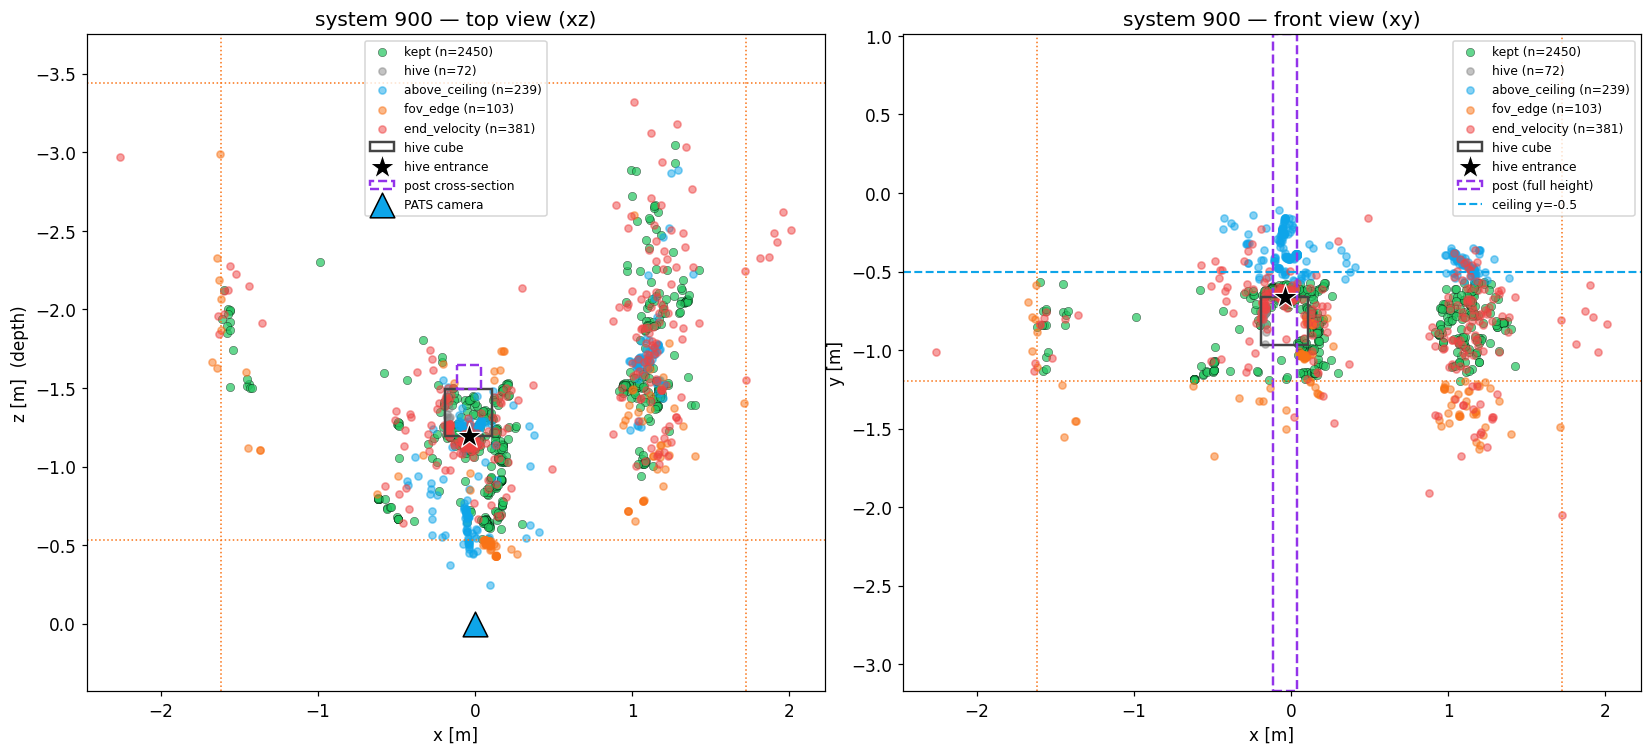

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# Robust defaults in case cell 2 wasn't re-run in this kernel
Y_CEILING_M       = globals().get("Y_CEILING_M",       -0.5)
HIVE_HALF_X       = globals().get("HIVE_HALF_X",       0.15)
HIVE_DOWN_Y       = globals().get("HIVE_DOWN_Y",       0.30)
HIVE_BACK_Z       = globals().get("HIVE_BACK_Z",       0.30)
POST_HALF_WIDTH_M = globals().get("POST_HALF_WIDTH_M", 0.075)
EDGE_BUFFER_M     = globals().get("EDGE_BUFFER_M",     0.15)
POST_XZ           = globals().get(
    "POST_XZ",
    {sid_: (h[0], h[2] - HIVE_BACK_Z - POST_HALF_WIDTH_M)
      for sid_, h in HIVE_XYZ.items()})

REASON_COLOUR = {"hive": "#888888", "post": "#9333EA",
                 "above_ceiling": "#0EA5E9", "fov_edge": "#F97316",
                 "end_velocity": "#EF4444"}

SID = 900
hx, hy, hz = HIVE_XYZ[SID]          # ENTRANCE point (top-front edge)
px, pz     = POST_XZ[SID]            # post centre (behind hive)
fb = fov_bounds[SID]
x_lo, x_hi = fb["x"]; y_lo, y_hi = fb["y"]; z_lo, z_hi = fb["z"]
sub_k = kept_df[kept_df["system_id"] == SID]
sub_r = rejected_df[rejected_df["system_id"] == SID]

fig, (axtop, axfront) = plt.subplots(1, 2, figsize=(15, 7))

# ─────────── TOP VIEW (xz) — camera at bottom of plot ───────────
axtop.scatter(sub_k["x"], sub_k["z"], s=30, c="#22C55E", alpha=0.7,
              edgecolor="black", linewidth=0.3, label=f"kept (n={len(sub_k)})")
for reason, c in REASON_COLOUR.items():
    s = sub_r[sub_r["filter_reason"] == reason]
    if len(s):
        axtop.scatter(s["x"], s["z"], s=22, c=c, alpha=0.5, label=f"{reason} (n={len(s)})")

# Hive cube (xz): extends BACK from the entrance line at z=hz to z=hz-HIVE_BACK_Z.
# In the inverted top view (camera at bottom), the hive's front face line is the
# edge of the box closest to the camera; that's exactly where the entrance dot
# sits.
axtop.add_patch(mpatches.Rectangle((hx - HIVE_HALF_X, hz - HIVE_BACK_Z),
                                   2*HIVE_HALF_X, HIVE_BACK_Z,
                                   fill=False, edgecolor="#444", linewidth=1.6,
                                   label="hive cube"))
# Hive entrance — sits on the camera-facing edge of the hive box
axtop.scatter([hx], [hz], marker="*", s=300, c="black", edgecolor="white",
              linewidth=0.8, zorder=10, label="hive entrance")

# Post (xz): 15×15 cm square BEHIND the hive, centred at (px, pz)
axtop.add_patch(mpatches.Rectangle((px - POST_HALF_WIDTH_M, pz - POST_HALF_WIDTH_M),
                                   2*POST_HALF_WIDTH_M, 2*POST_HALF_WIDTH_M,
                                   fill=False, edgecolor="#9333EA", linewidth=1.6,
                                   linestyle="--", label="post cross-section"))
# Camera marker at origin
axtop.scatter([0], [0], marker="^", s=260, c="#0EA5E9", edgecolor="black",
              linewidth=1.0, zorder=11, label="PATS camera")

# FOV-edge buffer
axtop.axvline(x_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axtop.axvline(x_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axtop.axhline(z_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axtop.axhline(z_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)

axtop.set_xlabel("x [m]")
axtop.set_ylabel("z [m]  (depth)")
axtop.set_title(f"system {SID} — top view (xz)")
axtop.legend(fontsize=8, loc="best")
axtop.set_aspect("equal", adjustable="datalim")
axtop.invert_yaxis()                    # camera (z=0) at BOTTOM, scene above

# ─────────── FRONT VIEW (xy) ───────────
axfront.scatter(sub_k["x"], sub_k["y"], s=30, c="#22C55E", alpha=0.7,
                edgecolor="black", linewidth=0.3, label=f"kept (n={len(sub_k)})")
for reason, c in REASON_COLOUR.items():
    s = sub_r[sub_r["filter_reason"] == reason]
    if len(s):
        axfront.scatter(s["x"], s["y"], s=22, c=c, alpha=0.5, label=f"{reason} (n={len(s)})")

# Hive cube (xy): entrance is at the TOP edge of the front face; the box
# extends DOWN by HIVE_DOWN_Y in y and is centred in x.  30 × 30 cm square.
axfront.add_patch(mpatches.Rectangle((hx - HIVE_HALF_X, hy - HIVE_DOWN_Y),
                                     2*HIVE_HALF_X, HIVE_DOWN_Y,
                                     fill=False, edgecolor="#444", linewidth=1.6,
                                     label="hive cube"))
# Hive entrance — top-centre of the hive cube in this projection
axfront.scatter([hx], [hy], marker="*", s=300, c="black", edgecolor="white",
                linewidth=0.8, zorder=10, label="hive entrance")

# Full-height post: axvspan covers the FULL plot height in y
axfront.axvspan(px - POST_HALF_WIDTH_M, px + POST_HALF_WIDTH_M,
                fill=False, edgecolor="#9333EA", linewidth=1.6, linestyle="--",
                label="post (full height)")
# Ceiling — dashed
axfront.axhline(Y_CEILING_M, color="#0EA5E9", linewidth=1.4, linestyle="--",
                label=f"ceiling y={Y_CEILING_M}")

# FOV-edge buffer
axfront.axvline(x_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axfront.axvline(x_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axfront.axhline(y_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
#axfront.axhline(y_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)

axfront.set_xlabel("x [m]")
axfront.set_ylabel("y [m]")
axfront.set_title(f"system {SID} — front view (xy)")
axfront.legend(fontsize=8, loc="best")
axfront.set_aspect("equal", adjustable="datalim")

plt.tight_layout(); plt.show()


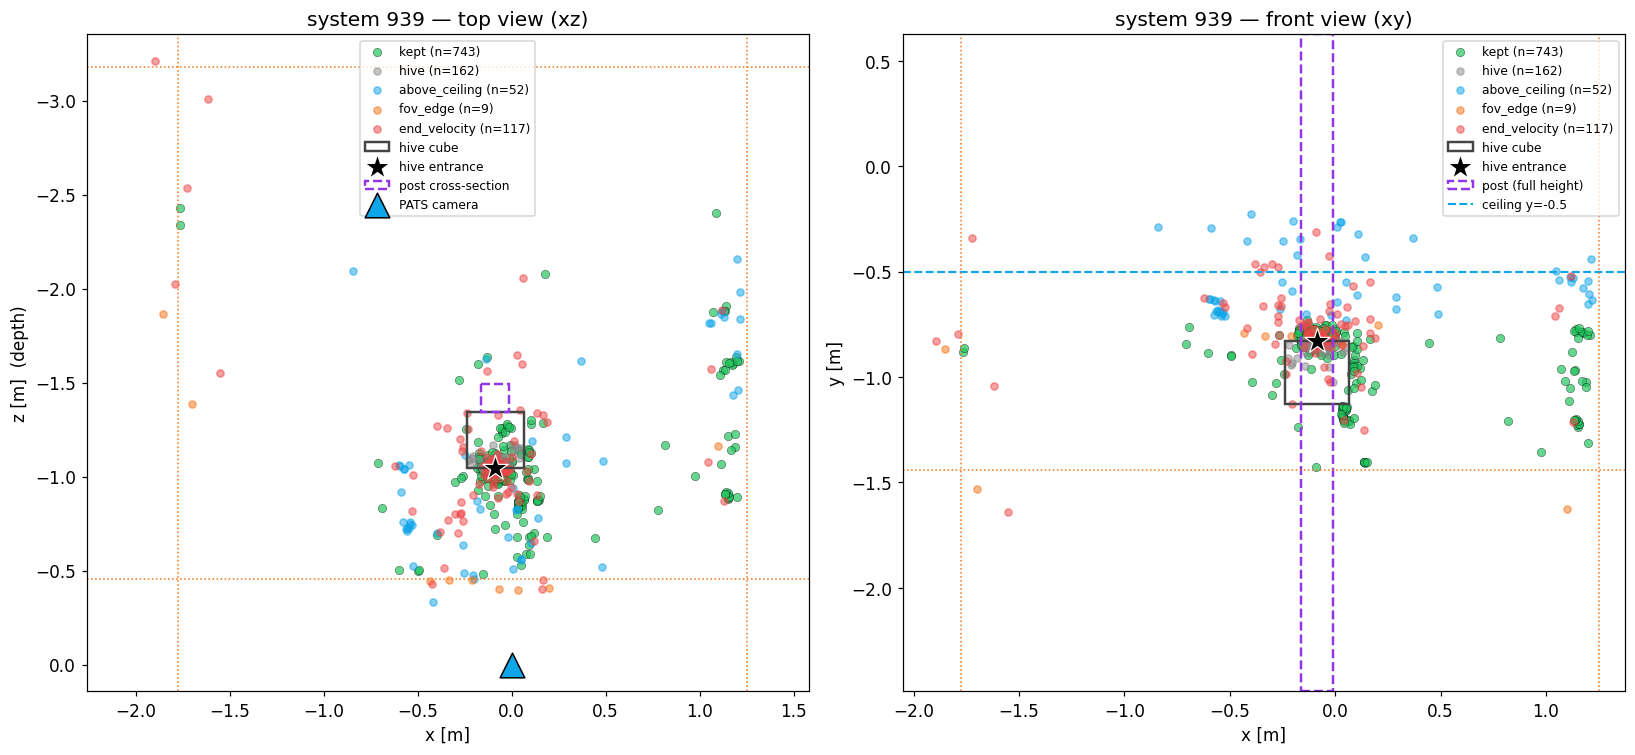

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# Robust defaults in case cell 2 wasn't re-run in this kernel
Y_CEILING_M       = globals().get("Y_CEILING_M",       -0.5)
HIVE_HALF_X       = globals().get("HIVE_HALF_X",       0.15)
HIVE_DOWN_Y       = globals().get("HIVE_DOWN_Y",       0.30)
HIVE_BACK_Z       = globals().get("HIVE_BACK_Z",       0.30)
POST_HALF_WIDTH_M = globals().get("POST_HALF_WIDTH_M", 0.075)
EDGE_BUFFER_M     = globals().get("EDGE_BUFFER_M",     0.15)
POST_XZ           = globals().get(
    "POST_XZ",
    {sid_: (h[0], h[2] - HIVE_BACK_Z - POST_HALF_WIDTH_M)
      for sid_, h in HIVE_XYZ.items()})

REASON_COLOUR = {"hive": "#888888", "post": "#9333EA",
                 "above_ceiling": "#0EA5E9", "fov_edge": "#F97316",
                 "end_velocity": "#EF4444"}

SID = 939
hx, hy, hz = HIVE_XYZ[SID]          # ENTRANCE point (top-front edge)
px, pz     = POST_XZ[SID]            # post centre (behind hive)
fb = fov_bounds[SID]
x_lo, x_hi = fb["x"]; y_lo, y_hi = fb["y"]; z_lo, z_hi = fb["z"]
sub_k = kept_df[kept_df["system_id"] == SID]
sub_r = rejected_df[rejected_df["system_id"] == SID]

fig, (axtop, axfront) = plt.subplots(1, 2, figsize=(15, 7))

# ─────────── TOP VIEW (xz) — camera at bottom of plot ───────────
axtop.scatter(sub_k["x"], sub_k["z"], s=30, c="#22C55E", alpha=0.7,
              edgecolor="black", linewidth=0.3, label=f"kept (n={len(sub_k)})")
for reason, c in REASON_COLOUR.items():
    s = sub_r[sub_r["filter_reason"] == reason]
    if len(s):
        axtop.scatter(s["x"], s["z"], s=22, c=c, alpha=0.5, label=f"{reason} (n={len(s)})")

# Hive cube (xz): extends BACK from the entrance line at z=hz to z=hz-HIVE_BACK_Z.
# In the inverted top view (camera at bottom), the hive's front face line is the
# edge of the box closest to the camera; that's exactly where the entrance dot
# sits.
axtop.add_patch(mpatches.Rectangle((hx - HIVE_HALF_X, hz - HIVE_BACK_Z),
                                   2*HIVE_HALF_X, HIVE_BACK_Z,
                                   fill=False, edgecolor="#444", linewidth=1.6,
                                   label="hive cube"))
# Hive entrance — sits on the camera-facing edge of the hive box
axtop.scatter([hx], [hz], marker="*", s=300, c="black", edgecolor="white",
              linewidth=0.8, zorder=10, label="hive entrance")

# Post (xz): 15×15 cm square BEHIND the hive, centred at (px, pz)
axtop.add_patch(mpatches.Rectangle((px - POST_HALF_WIDTH_M, pz - POST_HALF_WIDTH_M),
                                   2*POST_HALF_WIDTH_M, 2*POST_HALF_WIDTH_M,
                                   fill=False, edgecolor="#9333EA", linewidth=1.6,
                                   linestyle="--", label="post cross-section"))
# Camera marker at origin
axtop.scatter([0], [0], marker="^", s=260, c="#0EA5E9", edgecolor="black",
              linewidth=1.0, zorder=11, label="PATS camera")

# FOV-edge buffer
axtop.axvline(x_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axtop.axvline(x_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axtop.axhline(z_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axtop.axhline(z_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)

axtop.set_xlabel("x [m]")
axtop.set_ylabel("z [m]  (depth)")
axtop.set_title(f"system {SID} — top view (xz)")
axtop.legend(fontsize=8, loc="best")
axtop.set_aspect("equal", adjustable="datalim")
axtop.invert_yaxis()                    # camera (z=0) at BOTTOM, scene above

# ─────────── FRONT VIEW (xy) ───────────
axfront.scatter(sub_k["x"], sub_k["y"], s=30, c="#22C55E", alpha=0.7,
                edgecolor="black", linewidth=0.3, label=f"kept (n={len(sub_k)})")
for reason, c in REASON_COLOUR.items():
    s = sub_r[sub_r["filter_reason"] == reason]
    if len(s):
        axfront.scatter(s["x"], s["y"], s=22, c=c, alpha=0.5, label=f"{reason} (n={len(s)})")

# Hive cube (xy): entrance is at the TOP edge of the front face; the box
# extends DOWN by HIVE_DOWN_Y in y and is centred in x.  30 × 30 cm square.
axfront.add_patch(mpatches.Rectangle((hx - HIVE_HALF_X, hy - HIVE_DOWN_Y),
                                     2*HIVE_HALF_X, HIVE_DOWN_Y,
                                     fill=False, edgecolor="#444", linewidth=1.6,
                                     label="hive cube"))
# Hive entrance — top-centre of the hive cube in this projection
axfront.scatter([hx], [hy], marker="*", s=300, c="black", edgecolor="white",
                linewidth=0.8, zorder=10, label="hive entrance")

# Full-height post: axvspan covers the FULL plot height in y
axfront.axvspan(px - POST_HALF_WIDTH_M, px + POST_HALF_WIDTH_M,
                fill=False, edgecolor="#9333EA", linewidth=1.6, linestyle="--",
                label="post (full height)")
# Ceiling — dashed
axfront.axhline(Y_CEILING_M, color="#0EA5E9", linewidth=1.4, linestyle="--",
                label=f"ceiling y={Y_CEILING_M}")

# FOV-edge buffer
axfront.axvline(x_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axfront.axvline(x_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
axfront.axhline(y_lo + EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)
#axfront.axhline(y_hi - EDGE_BUFFER_M, color="#F97316", linestyle=":", linewidth=1)

axfront.set_xlabel("x [m]")
axfront.set_ylabel("y [m]")
axfront.set_title(f"system {SID} — front view (xy)")
axfront.legend(fontsize=8, loc="best")
axfront.set_aspect("equal", adjustable="datalim")

plt.tight_layout(); plt.show()


## 5b. Per-visit inspection — uids + trajectories (download by uid)

Pick a `(date, system)` and this section prints every kept visit's **uids and
wall-clock start/end**, then plots the *raw* trajectory of each involved track
(xy + xz projections) with the hive box, full-height post and ceiling overlaid.
Use the printed `UIDs to download` list to pull the corresponding videos.


44 kept visits on 2026-04-22 — system 900

source            uids  t_start    t_end  duration_s      x      y      z  dist_hive_m  flower_id
within         1477765 08:44:50 08:44:51       1.124  0.087 -1.007 -0.623        0.678          0
within         1481679 10:37:57 10:37:58       1.447 -0.040 -0.641 -1.142        0.059          1
within         1481811 10:41:00 10:41:01       1.046 -0.068 -0.650 -1.135        0.068          1
within         1482251 10:53:18 10:53:20       2.526  0.072 -0.997 -0.632        0.663          0
within         1482569 11:05:10 11:05:11       1.001 -0.022 -0.652 -1.161        0.041          1
within         1482792 11:13:13 11:13:15       2.048  0.075 -1.001 -0.634        0.664          0
within         1482911 11:16:45 11:16:46       1.146 -0.039 -0.649 -1.144        0.053          1
within         1483421 11:27:04 11:27:06       1.814 -0.561 -1.161 -0.734        0.854          2
within         1483485 11:28:39 11:28:44       5.019  0.075 -1.002 -0.633  

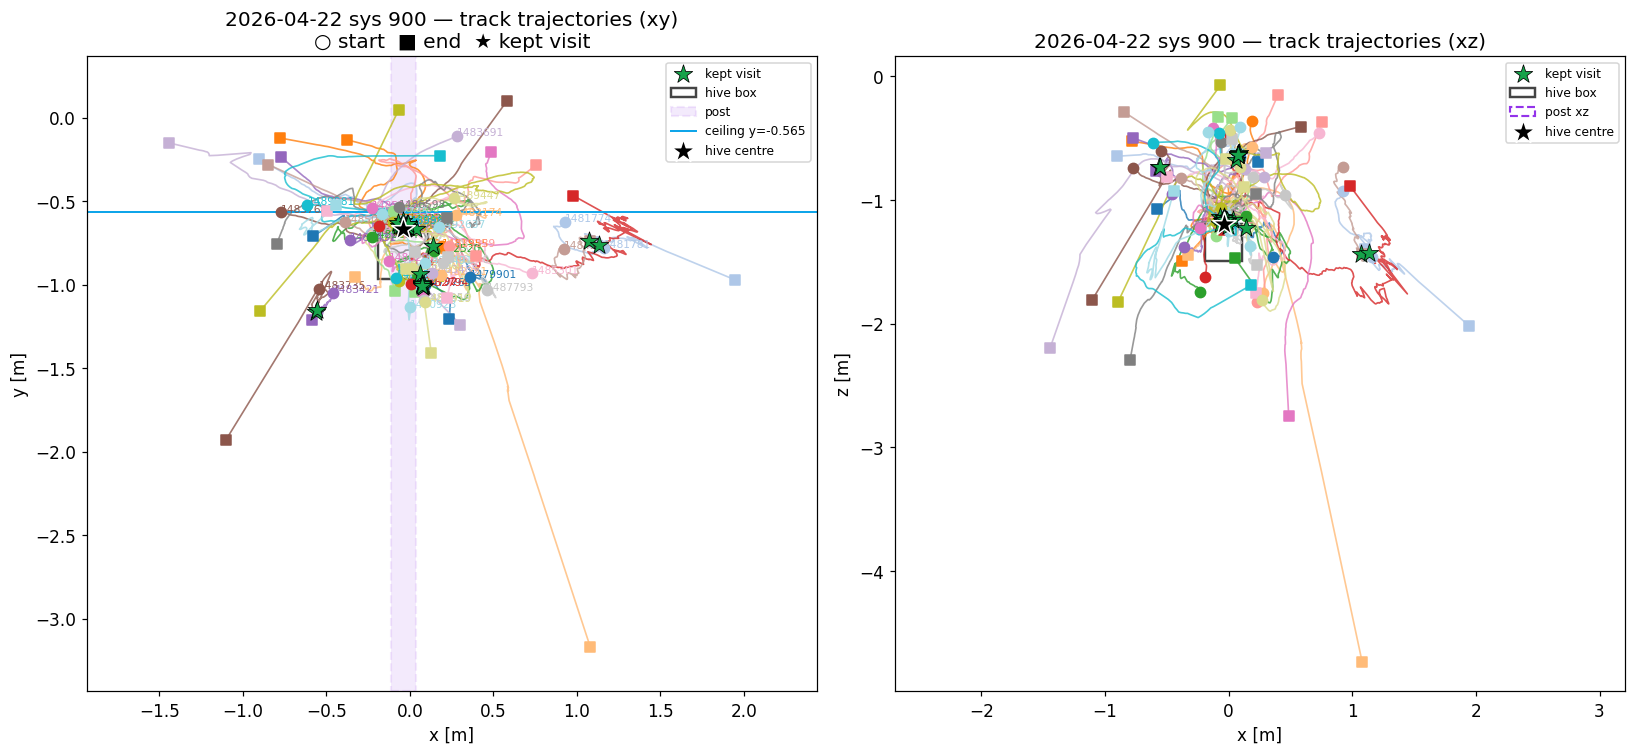

In [8]:
# ── Per-visit inspection: choose a day + system ──
VIZ_DATE = "2026-04-22"
VIZ_SYS  = 900

viz = kept_df[(kept_df["date"] == VIZ_DATE) & (kept_df["system_id"] == VIZ_SYS)].copy()
print(f"{len(viz)} kept visits on {VIZ_DATE} — system {VIZ_SYS}\n")

if len(viz):
    show = viz[["source", "uids", "t_start_dt", "t_end_dt", "duration_s",
                "x", "y", "z", "dist_hive_m", "flower_id"]].copy()
    # show wall-clock as HH:MM:SS for readability
    # ISO8601 handles mixed precision: within-visits carry microseconds, cross-visits land on whole seconds
    show["t_start"] = pd.to_datetime(show["t_start_dt"], format="ISO8601", errors="coerce").dt.strftime("%H:%M:%S")
    show["t_end"]   = pd.to_datetime(show["t_end_dt"],   format="ISO8601", errors="coerce").dt.strftime("%H:%M:%S")
    show = show[["source", "uids", "t_start", "t_end", "duration_s", "x", "y", "z", "dist_hive_m", "flower_id"]]
    with pd.option_context("display.max_rows", None, "display.width", 160):
        print(show.round(3).to_string(index=False))

    all_uids = sorted({int(u) for us in viz["uids"] for u in str(us).split(";")})
    print(f"\nUIDs to download ({len(all_uids)}): " + ", ".join(map(str, all_uids)))

    # ── plot raw trajectories of the involved tracks ──
    hx, hy, hz = HIVE_XYZ[VIZ_SYS]
    fb = fov_bounds[VIZ_SYS]; y_lo, y_hi = fb["y"]
    folder = DATA_BASE / f"{VIZ_DATE}_system_{VIZ_SYS}"
    ftv = pd.read_csv(folder / "flight_tracks.csv",
                      usecols=["detection_uid", "elapsed",
                               "sposX_insect", "sposY_insect", "sposZ_insect"])
    ftv = ftv[ftv["detection_uid"].isin(all_uids)]

    cmap = plt.cm.get_cmap("tab20", max(len(all_uids), 1))
    fig, (axxy, axxz) = plt.subplots(1, 2, figsize=(15, 7))
    for k, uid in enumerate(all_uids):
        trk = ftv[ftv["detection_uid"] == uid].sort_values("elapsed")
        if trk.empty: continue
        c = cmap(k)
        axxy.plot(trk["sposX_insect"], trk["sposY_insect"], "-", color=c, lw=1.1, alpha=0.8)
        axxy.scatter(trk["sposX_insect"].iloc[0], trk["sposY_insect"].iloc[0], color=c, marker="o", s=45, zorder=5)
        axxy.scatter(trk["sposX_insect"].iloc[-1], trk["sposY_insect"].iloc[-1], color=c, marker="s", s=45, zorder=5)
        axxy.annotate(str(uid), (trk["sposX_insect"].iloc[0], trk["sposY_insect"].iloc[0]),
                      fontsize=7, color=c)
        axxz.plot(trk["sposX_insect"], trk["sposZ_insect"], "-", color=c, lw=1.1, alpha=0.8)
        axxz.scatter(trk["sposX_insect"].iloc[0], trk["sposZ_insect"].iloc[0], color=c, marker="o", s=45, zorder=5)
        axxz.scatter(trk["sposX_insect"].iloc[-1], trk["sposZ_insect"].iloc[-1], color=c, marker="s", s=45, zorder=5)

    # kept-visit points
    axxy.scatter(viz["x"], viz["y"], marker="*", s=160, c="#16A34A", edgecolor="black",
                 linewidth=0.5, zorder=8, label="kept visit")
    axxz.scatter(viz["x"], viz["z"], marker="*", s=160, c="#16A34A", edgecolor="black",
                 linewidth=0.5, zorder=8, label="kept visit")

    # hive box + post + ceiling (xy)
    axxy.add_patch(mpatches.Rectangle((hx-HIVE_HALF_X, hy-HIVE_DOWN_Y), 2*HIVE_HALF_X, HIVE_DOWN_Y,
                                      fill=False, edgecolor="#444", lw=1.6, label="hive box"))
    axxy.axvspan(hx-POST_HALF_WIDTH_M, hx+POST_HALF_WIDTH_M,
                 facecolor="#9333EA", alpha=0.10, edgecolor="#9333EA", lw=1.4, ls="--", label="post")
    _y_ceiling = hy + Y_CEILING_BUFFER_M
    axxy.axhline(_y_ceiling, color="#0EA5E9", lw=1.3, label=f"ceiling y={_y_ceiling:.3f}")
    axxy.scatter([hx], [hy], marker="*", s=260, c="black", edgecolor="white", zorder=10, label="hive centre")
    # hive box + post (xz)
    axxz.add_patch(mpatches.Rectangle((hx-HIVE_HALF_X, hz-HIVE_BACK_Z), 2*HIVE_HALF_X, HIVE_BACK_Z,
                                      fill=False, edgecolor="#444", lw=1.6, label="hive box"))
    axxz.add_patch(mpatches.Rectangle((hx-POST_HALF_WIDTH_M, hz-POST_HALF_WIDTH_M),
                                      2*POST_HALF_WIDTH_M, 2*POST_HALF_WIDTH_M,
                                      fill=False, edgecolor="#9333EA", lw=1.4, ls="--", label="post xz"))
    axxz.scatter([hx], [hz], marker="*", s=260, c="black", edgecolor="white", zorder=10, label="hive centre")

    axxy.set_xlabel("x [m]"); axxy.set_ylabel("y [m]")
    axxy.set_title(f"{VIZ_DATE} sys {VIZ_SYS} — track trajectories (xy)\n○ start  ■ end  ★ kept visit")
    axxy.legend(fontsize=8, loc="best"); axxy.set_aspect("equal", adjustable="datalim")
    axxz.set_xlabel("x [m]"); axxz.set_ylabel("z [m]")
    axxz.set_title(f"{VIZ_DATE} sys {VIZ_SYS} — track trajectories (xz)")
    axxz.legend(fontsize=8, loc="best"); axxz.set_aspect("equal", adjustable="datalim")
    plt.tight_layout(); plt.show()
else:
    print("No kept visits for this (date, system) — pick another VIZ_DATE / VIZ_SYS.")


## 6. Deceleration diagnostic

Three panels for the cross-track candidates:

1. **End-mean speed** — kept (passed deceleration gate) vs rejected.
2. **End slope of speed** — should skew negative for kept, near-zero/positive for rejected.
3. **Drop-ratio (second_half / first_half)** — kept should cluster
   below `DECEL_DROP_RATIO`; rejected near 1.0 (steady speed).


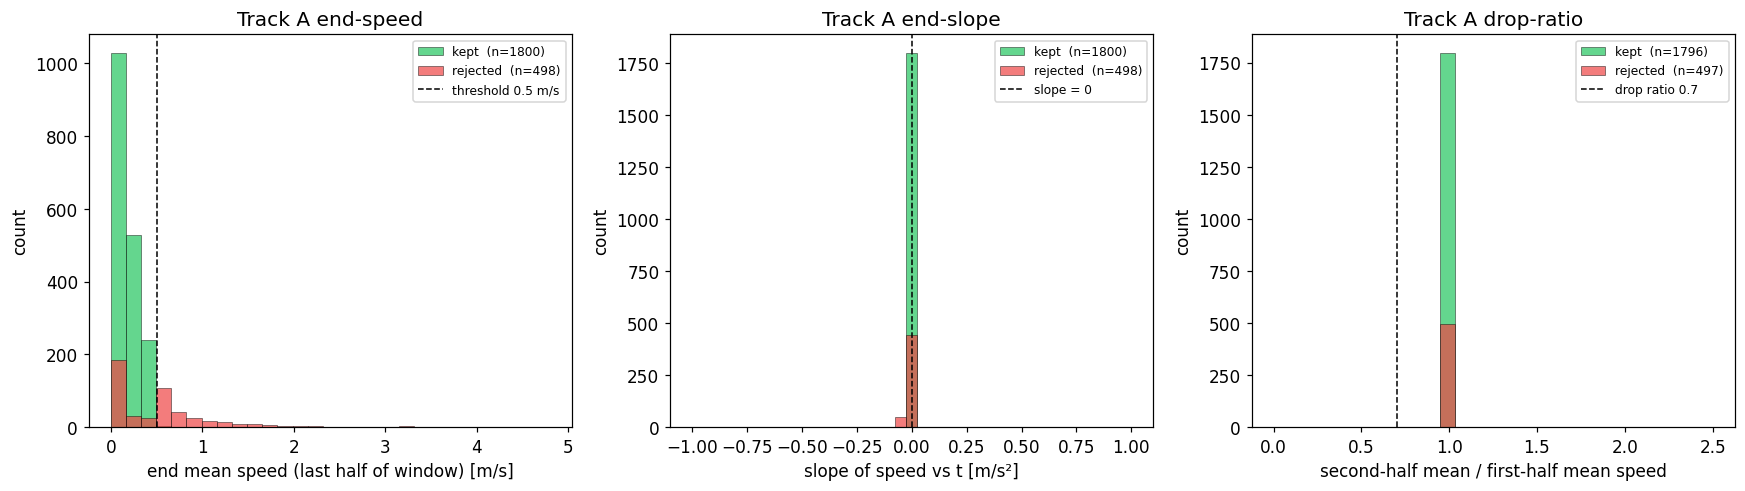

Cross-track deceleration stats:
  kept end speed:     median=0.143, max=0.498
  rejected end speed: median=0.507, max=4.801

Why each rejected cross-track failed:
decel_fail_reason
end_v_too_high     255
no_deceleration    243


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

kept_cross = kept_df[kept_df["source"] == "cross"]
rej_endv   = rejected_df[rejected_df["filter_reason"] == "end_velocity"]

# 1) end speed
ax = axes[0]
kv = kept_cross["end_v_a"].dropna()
rv = rej_endv["end_v_a"].dropna()
hi = max(2.5, rv.max() if len(rv) else 2.5)
bins = np.linspace(0, hi, 30)
ax.hist(kv, bins=bins, alpha=0.7, color="#22C55E",
        label=f"kept  (n={len(kv)})", edgecolor="black", linewidth=0.4)
ax.hist(rv, bins=bins, alpha=0.7, color="#EF4444",
        label=f"rejected  (n={len(rv)})", edgecolor="black", linewidth=0.4)
ax.axvline(DECEL_END_THR_MS, color="black", linestyle="--", linewidth=1,
           label=f"threshold {DECEL_END_THR_MS} m/s")
ax.set_xlabel("end mean speed (last half of window) [m/s]")
ax.set_ylabel("count"); ax.set_title("Track A end-speed"); ax.legend(fontsize=8)

# 2) end slope
ax = axes[1]
ks = kept_cross["end_slope_a"].dropna()
rs = rej_endv["end_slope_a"].dropna()
edge = max(abs(ks).max() if len(ks) else 1, abs(rs).max() if len(rs) else 1, 1.0)
bins = np.linspace(-edge, edge, 40)
ax.hist(ks, bins=bins, alpha=0.7, color="#22C55E",
        label=f"kept  (n={len(ks)})", edgecolor="black", linewidth=0.4)
ax.hist(rs, bins=bins, alpha=0.7, color="#EF4444",
        label=f"rejected  (n={len(rs)})", edgecolor="black", linewidth=0.4)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1, label="slope = 0")
ax.set_xlabel("slope of speed vs t [m/s²]")
ax.set_ylabel("count"); ax.set_title("Track A end-slope"); ax.legend(fontsize=8)

# 3) drop ratio
ax = axes[2]
def _ratio(df):
    a = df["end_first_half_v_a"]; b = df["end_second_half_v_a"]
    mask = (a > 1e-3) & a.notna() & b.notna()
    return (b[mask] / a[mask])
kr = _ratio(kept_cross); rr = _ratio(rej_endv)
bins = np.linspace(0, 2.5, 30)
ax.hist(kr, bins=bins, alpha=0.7, color="#22C55E",
        label=f"kept  (n={len(kr)})", edgecolor="black", linewidth=0.4)
ax.hist(rr, bins=bins, alpha=0.7, color="#EF4444",
        label=f"rejected  (n={len(rr)})", edgecolor="black", linewidth=0.4)
ax.axvline(DECEL_DROP_RATIO, color="black", linestyle="--", linewidth=1,
           label=f"drop ratio {DECEL_DROP_RATIO}")
ax.set_xlabel("second-half mean / first-half mean speed")
ax.set_ylabel("count"); ax.set_title("Track A drop-ratio"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print("Cross-track deceleration stats:")
if len(kv):
    print(f"  kept end speed:     median={kv.median():.3f}, max={kv.max():.3f}")
if len(rv):
    print(f"  rejected end speed: median={rv.median():.3f}, max={rv.max():.3f}")
if "decel_fail_reason" in rej_endv.columns:
    sub_reasons = rej_endv["decel_fail_reason"].value_counts()
    if len(sub_reasons):
        print("\nWhy each rejected cross-track failed:")
        print(sub_reasons.to_string())


## 7. Per-track velocity example: kept vs rejected

For a quick visual sanity-check, plot the trailing speed-vs-time profile
of one kept and one rejected cross-track candidate.  A well-decelerating
landing should show speed dropping toward the end; a tracking-dropout
artefact should show roughly constant speed.


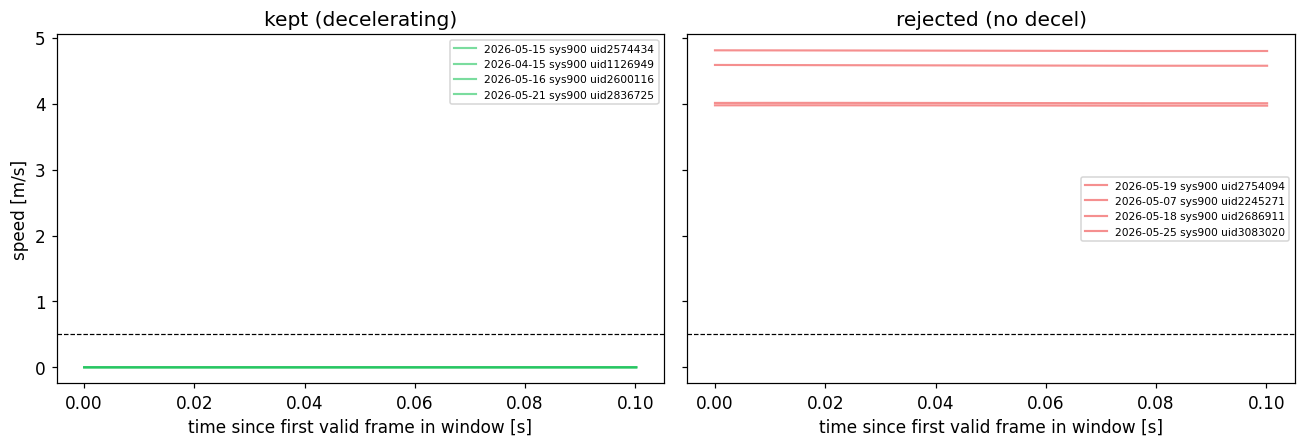

In [10]:
def _trailing_profile(date, sid, uid, n=VEL_WINDOW):
    folder = DATA_BASE / f"{date}_system_{sid}"
    ft_csv = folder / "flight_tracks.csv"
    if not ft_csv.exists(): return None
    ft = pd.read_csv(ft_csv, usecols=["detection_uid","elapsed",
                                       "svelX_insect","svelY_insect","svelZ_insect",
                                       "vel_valid_insect"])
    sub = ft[ft["detection_uid"] == int(uid)].sort_values("elapsed")
    sub = sub[sub["vel_valid_insect"] == 1]
    if len(sub) < 4: return None
    tail = sub.tail(n)
    t = tail["elapsed"].values - tail["elapsed"].values[0]
    sp = np.sqrt(tail["svelX_insect"]**2 + tail["svelY_insect"]**2 + tail["svelZ_insect"]**2).values
    return t, sp

def _first_uid(row):
    u = row["uids"].split(";")[0]
    try: return int(u)
    except: return None

# pick one kept and one rejected cross-track (deepest median candidate)
kept_cross_sorted = kept_df[kept_df["source"] == "cross"].sort_values("end_v_a")
rej_endv_sorted   = rejected_df[(rejected_df["filter_reason"] == "end_velocity")].sort_values("end_v_a", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, label, df_sorted, color in [
        (axes[0], "kept (decelerating)", kept_cross_sorted, "#22C55E"),
        (axes[1], "rejected (no decel)", rej_endv_sorted,   "#EF4444")]:
    plotted = 0
    for _, r in df_sorted.head(6).iterrows():
        uid = _first_uid(r)
        if uid is None: continue
        prof = _trailing_profile(r["date"], r["system_id"], uid)
        if prof is None: continue
        t, sp = prof
        ax.plot(t, sp, color=color, alpha=0.6, linewidth=1.4,
                label=f"{r['date']} sys{r['system_id']} uid{uid}")
        plotted += 1
        if plotted >= 4: break
    ax.axhline(DECEL_END_THR_MS, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel("time since first valid frame in window [s]")
    ax.legend(fontsize=7, loc="best")
axes[0].set_ylabel("speed [m/s]")
plt.tight_layout(); plt.show()


## 8. Condition comparison (final indicators)

Box-and-strip plots per indicator × system, BASELINE / OFF / ON.
y-axis is shared within each row (per project conventions for box plots
shown side-by-side).


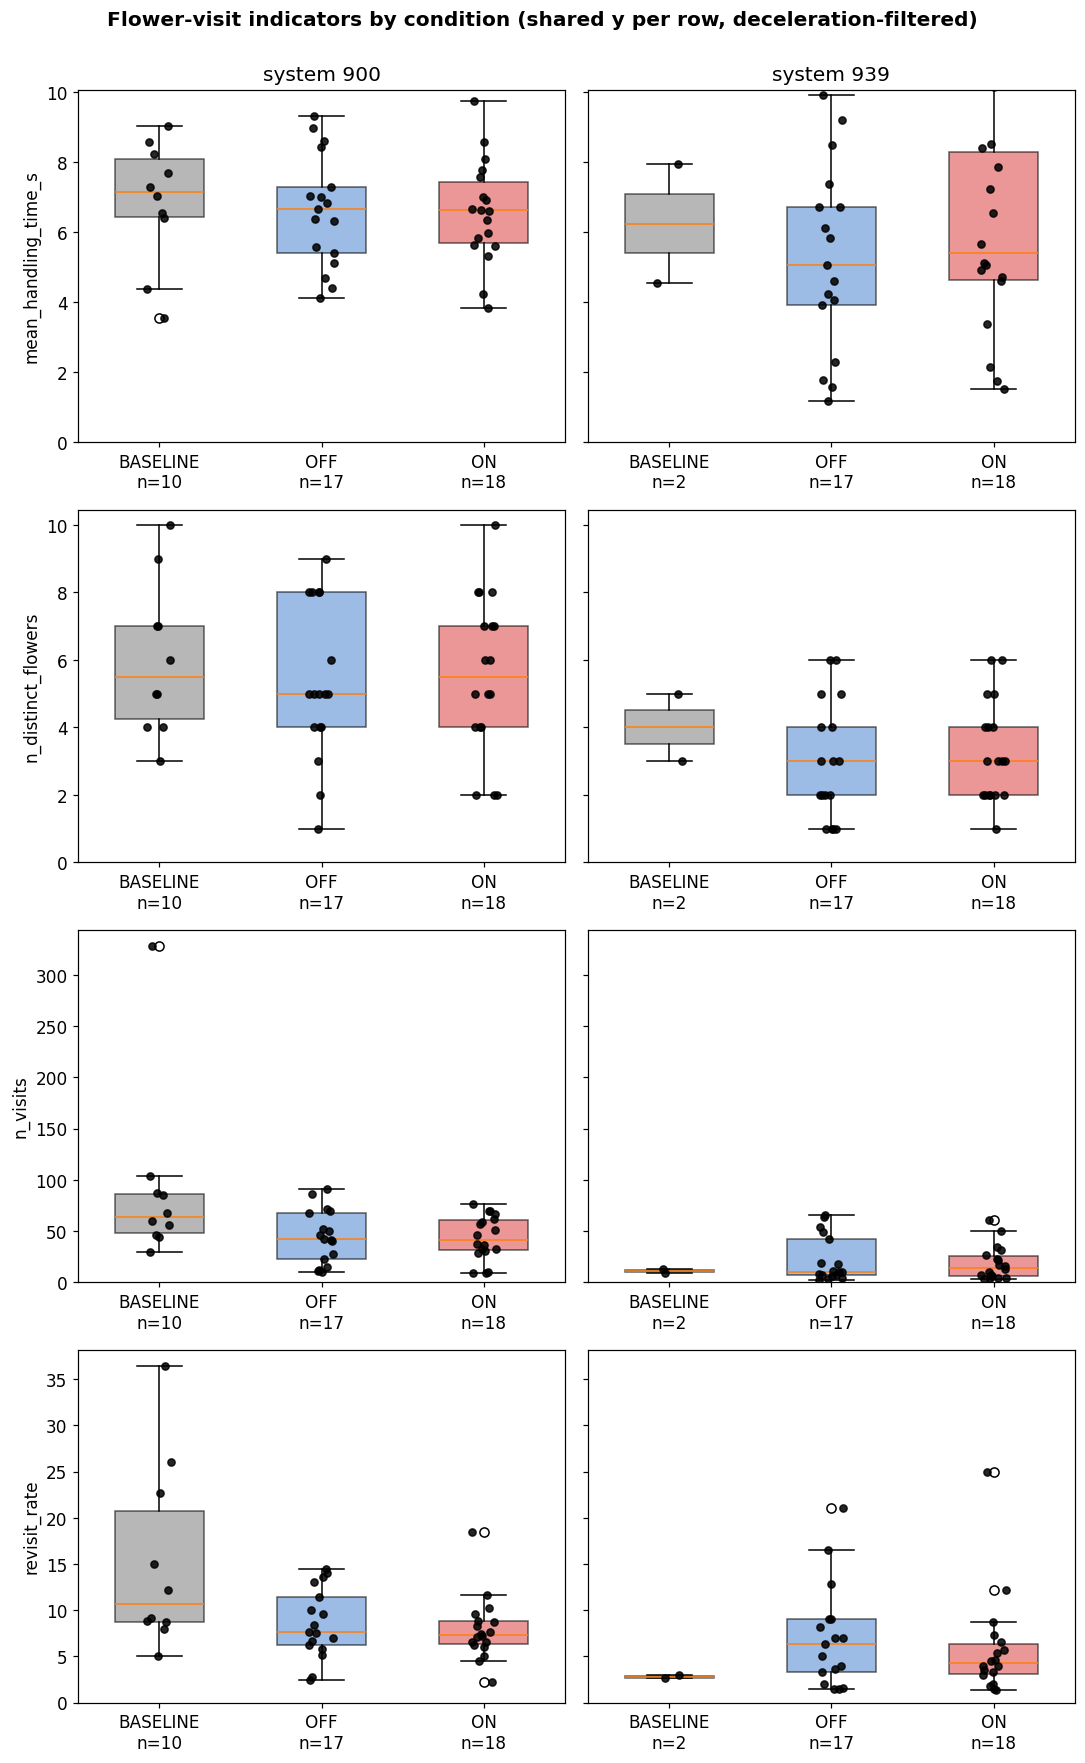

Median values by (system, condition):
sys 900:
  mean_handling_time_s          BASELINE=7.16(n=10)  OFF=6.65(n=17)  ON=6.62(n=18)
  n_distinct_flowers            BASELINE=5.50(n=10)  OFF=5.00(n=17)  ON=5.50(n=18)
  n_visits                      BASELINE=64.00(n=10)  OFF=42.00(n=17)  ON=41.50(n=18)
  revisit_rate                  BASELINE=10.67(n=10)  OFF=7.67(n=17)  ON=7.31(n=18)
sys 939:
  mean_handling_time_s          BASELINE=6.24(n=2)  OFF=5.07(n=17)  ON=5.40(n=18)
  n_distinct_flowers            BASELINE=4.00(n=2)  OFF=3.00(n=17)  ON=3.00(n=18)
  n_visits                      BASELINE=11.00(n=2)  OFF=10.00(n=17)  ON=14.50(n=18)
  revisit_rate                  BASELINE=2.80(n=2)  OFF=6.33(n=17)  ON=4.25(n=18)


In [11]:
CYCLE_ANCHOR = pd.Timestamp("2026-04-23")
# Calendar overrides (decided after the field campaign):
EXCLUDED_DATES = {pd.Timestamp("2026-05-26")}   # Narda calibration — personnel in greenhouse
OFF_OVERRIDE   = {pd.Timestamp("2026-05-29")}   # OFF block extended one day to maintain 3-day window

def label_date(d):
    d = pd.Timestamp(d)
    if d in EXCLUDED_DATES: return "EXCLUDED"
    if d in OFF_OVERRIDE:   return "OFF"
    if d < CYCLE_ANCHOR:    return "BASELINE"
    return "ON" if ((d - CYCLE_ANCHOR).days // 3) % 2 == 0 else "OFF"

summary_df["date_ts"]   = pd.to_datetime(summary_df["date"])
summary_df["condition"] = summary_df["date_ts"].apply(label_date)

INDICATORS = ["mean_handling_time_s", "n_distinct_flowers", "n_visits", "revisit_rate"]
ORDER = ["BASELINE", "OFF", "ON"]
COND_COLOUR = {"BASELINE": "#888888", "OFF": "#5B8FD4", "ON": "#E05252"}

systems = sorted(summary_df["system_id"].unique())
fig, axes = plt.subplots(len(INDICATORS), len(systems),
                         figsize=(5 * len(systems), 4 * len(INDICATORS)),
                         sharey="row", squeeze=False)
for row, ind in enumerate(INDICATORS):
    for col, sid in enumerate(systems):
        ax = axes[row][col]
        data, labels, colors = [], [], []
        for cond in ORDER:
            vals = summary_df.loc[(summary_df["system_id"] == sid) &
                                   (summary_df["condition"] == cond), ind].dropna()
            data.append(vals); labels.append(f"{cond}\nn={len(vals)}"); colors.append(COND_COLOUR[cond])
        bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55)
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        for i, vals in enumerate(data):
            ax.scatter(np.full(len(vals), i+1) + np.random.uniform(-0.08, 0.08, len(vals)),
                       vals, color="black", s=22, alpha=0.85, zorder=3)
        if row == 0: ax.set_title(f"system {sid}")
        if col == 0: ax.set_ylabel(ind)
        ax.set_ylim(bottom=0)
fig.suptitle("Flower-visit indicators by condition (shared y per row, deceleration-filtered)",
             fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

print("Median values by (system, condition):")
for sid in systems:
    sub = summary_df[summary_df["system_id"] == sid]
    print(f"sys {sid}:")
    for ind in INDICATORS:
        meds = sub.groupby("condition")[ind].median().reindex(ORDER)
        ns   = sub.groupby("condition")[ind].count().reindex(ORDER)
        parts = []
        for c in ORDER:
            v = meds[c]; n = ns[c]
            parts.append(f"{c}={v:.2f}(n={int(n)})" if pd.notna(v) else f"{c}=NaN(n={int(n)})")
        print(f"  {ind:<28s}  " + "  ".join(parts))


## 9. Plug into `5g_foraging_effect_model.ipynb`

In the indicator-table cell of the model notebook, replace `median_ifi_s`
and `vertical_deviation` with the new flower-visit indicators:

```python
fv = pd.read_csv("data/multi_day/flower_visit_summary.csv")
fv["date"] = pd.to_datetime(fv["date"])
ind = ind.merge(fv[["date","system_id","mean_handling_time_s","n_distinct_flowers"]],
                on=["date","system_id"], how="left")

INDICATORS = [
    "neg_exit_count",         # foraging volume
    "neg_re_ratio",           # asymmetry of detection
    "path_tortuosity",        # navigation efficiency
    "ifi_cv",                 # foraging-rhythm regularity
    "mean_handling_time_s",   # Heinrich 1979 efficiency metric
    "n_distinct_flowers",     # flower-constancy proxy (Klein 2003)
]
```
